# 00 — Getting Started

zbi es un pipeline de SBI (Simulation-Based Inference) que entrena MAFs (Masked Autoregressive Flows) con truncamiento secuencial del prior (tSNPE). Está construido sobre PyTorch y nflows.

En este tutorial:
1. Definir un simulador y una red de embedding
2. Inicializar un experimento y simular 10000 datos
3. Entrenar 3 modelos por separado y compararlos

In [30]:
import os
import shutil
import torch
import matplotlib.pyplot as plt
from torch import nn
import zbi

%matplotlib inline

## 1. Simulador gaussiano

Detector que mide una señal en 100 puntos. La señal es una recta con pendiente $a$ e intercepto $b$, más ruido Gaussiano:

$$x_i = a \cdot g_i + b + \epsilon_i, \quad \epsilon_i \sim \mathcal{N}(0, 0.5)$$

In [31]:
class SimuladorLineal(zbi.Simulator):
    def __init__(self):
        super().__init__()
        self.x_grid = torch.linspace(-5, 5, 50)

    def simulate(self, theta: torch.Tensor, seed: int | None = None) -> torch.Tensor:
        if seed is not None:
            torch.manual_seed(seed)
        a, b = theta[0].item(), theta[1].item()
        return a * self.x_grid + b + 0.5 * torch.randn(50)

## 2. Red de embedding

Proyecta el dato de 100 dimensiones a 5 con una capa lineal.

In [32]:
class EmbeddingNet(nn.Module):
    def __init__(self, dim_in: int = 50, dim_out: int = 2):
        super().__init__()
        self.net = nn.Linear(dim_in, dim_out)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

## 3. Observación y experimento

Prior Uniforme en $[0.8, 0.2]$ y $[1.2, 0.8]$. Valor verdadero: $\theta_{\text{true}} = (1.0, 0.5)$.

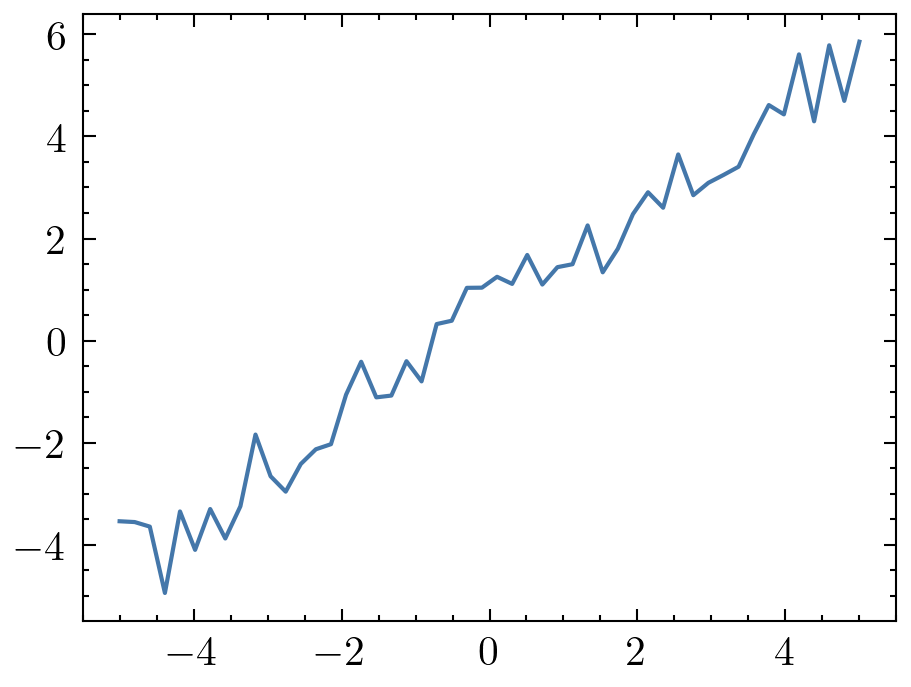

In [33]:
x_grid = torch.linspace(-5, 5, 50)
x_o = zbi.simulate_obs(SimuladorLineal(), theta_true=(1.0, 0.5), seed=42)
plt.plot(x_grid, x_o[0])

In [34]:
run_dir = "runs/tutorial_00"
if os.path.exists(run_dir):
    shutil.rmtree(run_dir)

zbi.init(
    run_dir=run_dir, x_o=x_o,
    simulator_class=SimuladorLineal,
    embedding_class=EmbeddingNet,
    embedding_kwargs=dict(dim_in=50, dim_out=2),
    prior_low=(0.8, 0.2), prior_high=(1.2, 0.8),
    dim_theta=2, dim_x=50,
    zarr_N=20000, zarr_chunk_size=128,
    maf_kwargs=dict(
        hidden_features=32, num_transforms=5,
        num_blocks=2, dropout_probability=0.0,
        use_batch_norm=False
    )
)

Experiment initialized: runs/tutorial_00


In [35]:
zbi.simulate(run_dir=run_dir, round=0, n_sims=10000, seed=1)

Simulating: 100%|██████████| 10000/10000 [00:01<00:00, 8251.88it/s]

Round 0: 10000 new sims, 10000 accumulated (offset=0)


## 4. Entrenamiento

Entrenamos 3 modelos independientes con `zbi.train`, cada uno con un `tag` distinto para que no se sobreescriban.

In [36]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

tags = ['a', 'b', 'c']
for tag in tags:
    print(f"Training model {tag}")
    zbi.train(
        run_dir=run_dir, 
        round=0, 
        n_sims=10000, 
        offset=0, 
        device=device,
        batch_size=128,
        lr=0.0005,
        max_epochs=200, 
        stop_after_epochs=200, 
        tag=tag, 
        interest_dims=None,
        load_to_ram=True
    )

Using device: cuda
Training model a
Using simulations: offset=0, n_sims=10000
Epoch   0  train_loss=-0.2867  val_loss=-1.4273
Epoch   1  train_loss=-1.7672  val_loss=-1.9263
Epoch   2  train_loss=-1.9885  val_loss=-2.0813
Epoch   3  train_loss=-2.2689  val_loss=-2.6286
Epoch   4  train_loss=-2.9570  val_loss=-3.2634
Epoch   5  train_loss=-3.3805  val_loss=-3.5351
Epoch   6  train_loss=-3.5308  val_loss=-3.5834
Epoch   7  train_loss=-3.6021  val_loss=-3.6192
Epoch   8  train_loss=-3.6217  val_loss=-3.6353
Epoch   9  train_loss=-3.6379  val_loss=-3.6569
Epoch  10  train_loss=-3.6415  val_loss=-3.6599
Epoch  11  train_loss=-3.6510  val_loss=-3.6784
Epoch  12  train_loss=-3.6595  val_loss=-3.6760
Epoch  13  train_loss=-3.6629  val_loss=-3.6721
Epoch  14  train_loss=-3.6699  val_loss=-3.6718
Epoch  15  train_loss=-3.6780  val_loss=-3.7079
Epoch  16  train_loss=-3.6752  val_loss=-3.6991
Epoch  17  train_loss=-3.6802  val_loss=-3.6916
Epoch  18  train_loss=-3.6852  val_loss=-3.7073
Epoch  19 

### Comparar los 3 modelos

Removed no burn in
Removed no burn in
Removed no burn in


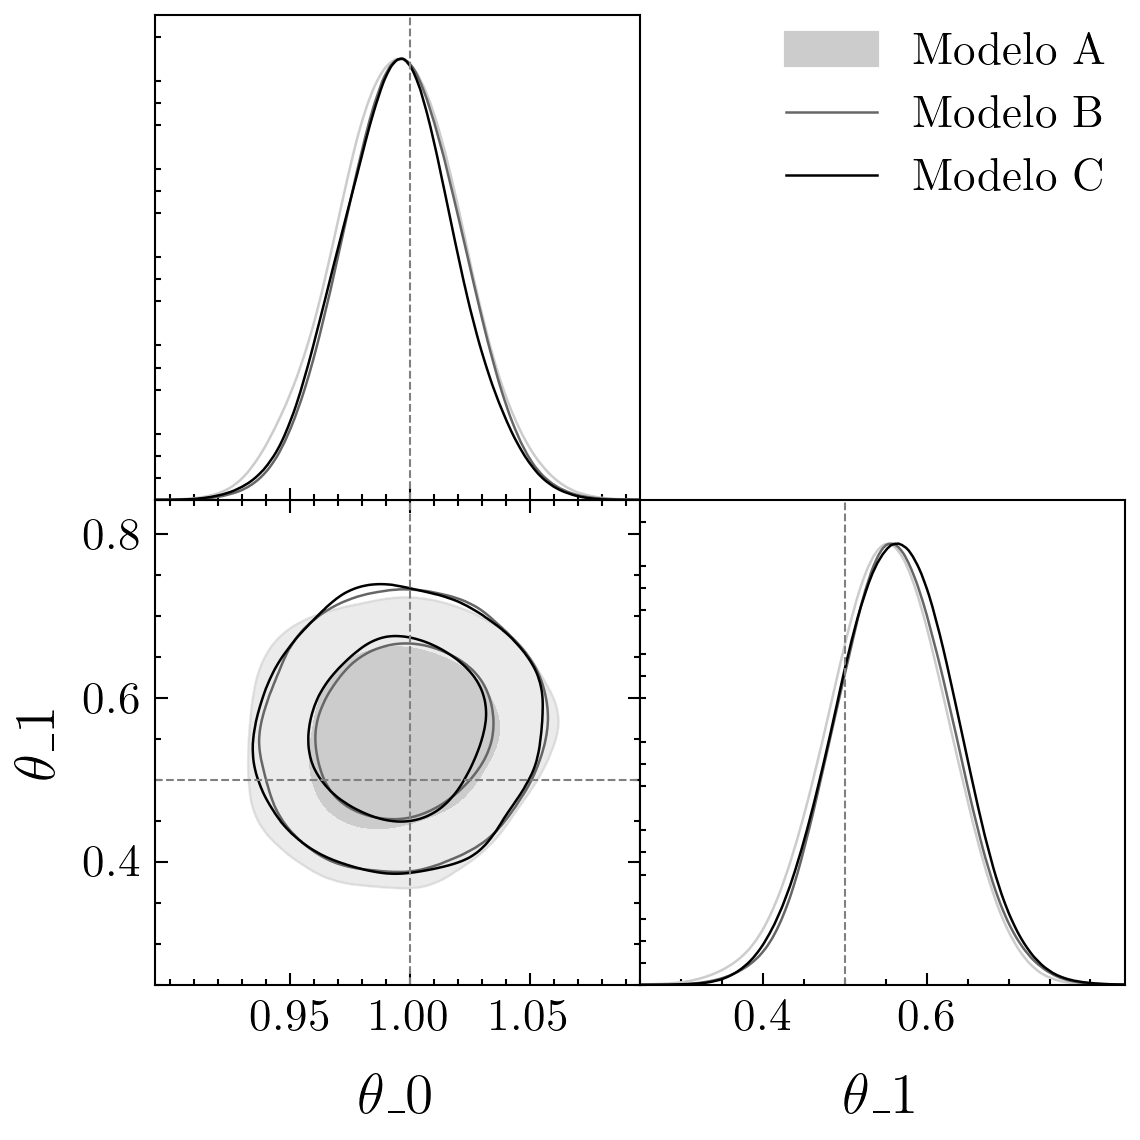

In [37]:
all_samples = []
for tag in tags:
    samples = zbi.sample_model(
        run_dir=run_dir,
        checkpoint=f"round_00000_10000_{tag}.pt",
        n_samples=10_000    
    )
    all_samples.append(samples)

zbi.plot_ppc(
    all_samples=all_samples,
    param_names=[r'\theta_0', r'\theta_1'],
    true_parameter=[1.0, 0.5],
    sample_labels=["Modelo A", "Modelo B", "Modelo C"],
    legend_fontsize=11,
    # limits=[(0.8, 1.2), (0.2, 0.8)],
    filled=[True, False, False],
    sample_colors=["#cccccc", "#666666", "#000000"],
    gdist_fine_bins=2000,
    gdist_scaling_factor=0.1
)

## Resumen

| Función | Descripción |
|---------|-------------|
| `zbi.init()` | Inicializa experimento |
| `zbi.simulate()` | Samplea del prior y guarda en ZarrStore |
| `zbi.train()` | Entrena un MAF individual |
| `zbi.sample_model()` | Genera muestras de la posterior |
| `zbi.plot_ppc()` | Corner plot con getdist |